In [ ]:
# # ============================================================
# # THIN-FILM DESIGN + DNN LDT + GA OPTIMIZATION + FIELD PLOTS
# # Google Colab Ready
# # ============================================================

# import numpy as np
# import random
# import matplotlib.pyplot as plt

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# import tensorflow as tf
# from tensorflow.keras import layers, models

# # ------------------------------------------------------------
# # 1. MATERIAL DISPERSION MODELS (real + complex)
# # ------------------------------------------------------------

# def cauchy_n(A, B, C, lam):
#     return A + B/(lam**2) + C/(lam**4)

# def absorption_k(k0, lam0, lam):
#     k = k0 * np.exp(-(lam - lam0)/150)
#     k[lam > lam0] = k0 * 0.1
#     return k

# materials = {
#     "SiO2": {
#         "n": lambda lam: cauchy_n(1.45, 1e4, 0, lam),
#         "k": lambda lam: absorption_k(1e-6, 200, lam)
#     },
#     "Ta2O5": {
#         "n": lambda lam: cauchy_n(2.1, 5e4, 0, lam),
#         "k": lambda lam: absorption_k(5e-4, 300, lam)
#     },
#     "HfO2": {
#         "n": lambda lam: cauchy_n(1.9, 4e4, 0, lam),
#         "k": lambda lam: absorption_k(1e-4, 250, lam)
#     },
#     "Al2O3": {
#         "n": lambda lam: cauchy_n(1.65, 2e4, 0, lam),
#         "k": lambda lam: absorption_k(5e-5, 220, lam)
#     }
# }

# material_list = list(materials.keys())

# # ------------------------------------------------------------
# # 2. TRANSFER MATRIX METHOD (TMM)
# # ------------------------------------------------------------

# def layer_matrix(n_complex, d, lam, theta_inc):
#     k0 = 2*np.pi/lam
#     theta = np.arcsin(np.real(1.0/n_complex) * np.sin(theta_inc))
#     kz = k0 * n_complex * np.cos(theta)
#     delta = kz * d
#     M = np.array([[np.cos(delta), 1j*np.sin(delta)/n_complex],
#                   [1j*n_complex*np.sin(delta), np.cos(delta)]])
#     return M

# def compute_reflectance(stack, thicknesses, lam_nm, theta_inc):
#     lam = lam_nm * 1e-9
#     M_tot = np.eye(2, dtype=complex)

#     for mat, d in zip(stack, thicknesses):
#         n = materials[mat]["n"](np.array([lam_nm]))[0]
#         k = materials[mat]["k"](np.array([lam_nm]))[0]
#         n_complex = n - 1j*k
#         M = layer_matrix(n_complex, d, lam, theta_inc)
#         M_tot = M_tot @ M

#     n0 = 1.0
#     ns = 1.5
#     r = (n0*M_tot[0,0] + n0*ns*M_tot[0,1] - M_tot[1,0] - ns*M_tot[1,1]) / \
#         (n0*M_tot[0,0] + n0*ns*M_tot[0,1] + M_tot[1,0] + ns*M_tot[1,1])

#     return np.abs(r)**2

# # ------------------------------------------------------------
# # 3. FIELD INTENSITY PROFILE INSIDE STACK
# # ------------------------------------------------------------

# def field_intensity_profile(stack, thicknesses, lam_nm, theta_inc, z_samples=400):
#     lam = lam_nm * 1e-9
#     n0 = 1.0
#     ns = 1.5
#     theta0 = theta_inc

#     # Build interface matrices and propagation matrices
#     n_layers = []
#     d_layers = []
#     for mat, d in zip(stack, thicknesses):
#         n = materials[mat]["n"](np.array([lam_nm]))[0]
#         k = materials[mat]["k"](np.array([lam_nm]))[0]
#         n_layers.append(n - 1j*k)
#         d_layers.append(d)
#     n_layers = np.array(n_layers)
#     d_layers = np.array(d_layers)

#     # Angles in each layer (Snell)
#     theta_layers = np.arcsin(np.real(n0/n_layers) * np.sin(theta0))

#     # Build global matrix and also store partial matrices
#     M_list = []
#     M_tot = np.eye(2, dtype=complex)
#     for n_l, d_l, th_l in zip(n_layers, d_layers, theta_layers):
#         k0 = 2*np.pi/lam
#         kz = k0 * n_l * np.cos(th_l)
#         delta = kz * d_l
#         M = np.array([[np.cos(delta), 1j*np.sin(delta)/n_l],
#                       [1j*n_l*np.sin(delta), np.cos(delta)]])
#         M_list.append(M)
#         M_tot = M_tot @ M

#     # Reflection coefficient at entrance
#     r = (n0*M_tot[0,0] + n0*ns*M_tot[0,1] - M_tot[1,0] - ns*M_tot[1,1]) / \
#         (n0*M_tot[0,0] + n0*ns*M_tot[0,1] + M_tot[1,0] + ns*M_tot[1,1])

#     # Incident field amplitude = 1
#     E0_plus = 1.0
#     E0_minus = r

#     # Now propagate layer by layer and compute |E|^2 vs depth
#     z = []
#     I = []
#     z_current = 0.0

#     E_plus = E0_plus
#     E_minus = E0_minus

#     for idx, (n_l, d_l, th_l) in enumerate(zip(n_layers, d_layers, theta_layers)):
#         k0 = 2*np.pi/lam
#         kz = k0 * n_l * np.cos(th_l)

#         # Sample inside this layer
#         z_local = np.linspace(0, d_l, max(5, int(z_samples/len(stack))))
#         for zl in z_local:
#             E_z = E_plus * np.exp(1j*kz*zl) + E_minus * np.exp(-1j*kz*zl)
#             z.append(z_current + zl)
#             I.append(np.abs(E_z)**2)

#         # Propagate to next layer: use interface matrix between layers
#         if idx < len(n_layers)-1:
#             n1 = n_l
#             n2 = n_layers[idx+1]
#             th1 = th_l
#             th2 = theta_layers[idx+1]
#             # Fresnel for TE
#             t12 = 2*n1*np.cos(th1)/(n1*np.cos(th1)+n2*np.cos(th2))
#             r12 = (n1*np.cos(th1)-n2*np.cos(th2))/(n1*np.cos(th1)+n2*np.cos(th2))
#             # Forward/backward amplitudes in next layer (simplified)
#             E_plus = t12*E_plus/(1 - r12*E_minus/E_plus + 1e-12)
#             E_minus = 0.0  # crude approximation: ignore backward from deeper layers

#         z_current += d_l

#     return np.array(z), np.array(I)

# # ------------------------------------------------------------
# # 4. SYNTHETIC LDT MODEL (heuristic)
# # ------------------------------------------------------------

# def synthetic_LDT(stack, thicknesses):
#     score = 0
#     for mat, d in zip(stack, thicknesses):
#         n_avg = np.mean(materials[mat]["n"](np.array([1064])))
#         score += (d * 1e9) / (n_avg**2)
#     return max(0.1, score / 1000)

# # ------------------------------------------------------------
# # 5. DATASET GENERATION
# # ------------------------------------------------------------

# MAX_FEATURES = 50

# def encode_sample(stack, thicknesses, R):
#     num_layers = len(stack)
#     feats = [R, num_layers]
#     feats += list(thicknesses * 1e9)
#     feats += [material_list.index(m) for m in stack]
#     if len(feats) < MAX_FEATURES:
#         feats += [0] * (MAX_FEATURES - len(feats))
#     else:
#         feats = feats[:MAX_FEATURES]
#     return feats

# def generate_dataset(N=1000, lam_center=1064, angle_deg=0):
#     X, y = [], []
#     theta = np.deg2rad(angle_deg)

#     for _ in range(N):
#         num_layers = random.randint(3, 10)
#         stack = [random.choice(material_list) for _ in range(num_layers)]
#         thicknesses = np.random.uniform(50e-9, 300e-9, num_layers)

#         R = compute_reflectance(stack, thicknesses, lam_center, theta)
#         LDT = synthetic_LDT(stack, thicknesses)

#         X.append(encode_sample(stack, thicknesses, R))
#         y.append(LDT)

#     return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# X, y = generate_dataset()

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # ------------------------------------------------------------
# # 6. DNN FOR LDT REGRESSION
# # ------------------------------------------------------------

# def build_dnn(input_dim):
#     model = models.Sequential()
#     model.add(layers.Input(shape=(input_dim,)))
#     model.add(layers.Dense(128, activation="relu"))
#     model.add(layers.Dense(128, activation="relu"))
#     model.add(layers.Dense(64, activation="relu"))
#     model.add(layers.Dense(32, activation="relu"))
#     model.add(layers.Dense(1, activation="linear"))
#     model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
#                   loss="mse",
#                   metrics=["mae"])
#     return model

# dnn = build_dnn(X_train_scaled.shape[1])

# history = dnn.fit(
#     X_train_scaled, y_train,
#     validation_split=0.2,
#     epochs=60,
#     batch_size=32,
#     verbose=1
# )

# test_loss, test_mae = dnn.evaluate(X_test_scaled, y_test, verbose=0)
# print(f"\nTest MSE: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

# # ------------------------------------------------------------
# # 7. UTILS: PLOTTING
# # ------------------------------------------------------------

# def plot_stacks(initial_stack, initial_thick, final_stack, final_thick):
#     unique_materials = list(set(initial_stack + final_stack))
#     cmap = plt.cm.get_cmap('tab20', len(unique_materials))
#     color_map = {mat: cmap(i) for i, mat in enumerate(unique_materials)}

#     fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

#     ax = axes[0]
#     ax.bar(range(len(initial_stack)), initial_thick * 1e9,
#            color=[color_map[m] for m in initial_stack])
#     ax.set_title("Initial Thin-Film Stack")
#     ax.set_xlabel("Layer Index")
#     ax.set_ylabel("Thickness (nm)")
#     ax.set_xticks(range(len(initial_stack)))
#     ax.set_xticklabels(initial_stack, rotation=45, ha='right')

#     ax = axes[1]
#     ax.bar(range(len(final_stack)), final_thick * 1e9,
#            color=[color_map[m] for m in final_stack])
#     ax.set_title("Optimized Thin-Film Stack")
#     ax.set_xlabel("Layer Index")
#     ax.set_xticks(range(len(final_stack)))
#     ax.set_xticklabels(final_stack, rotation=45, ha='right')

#     handles = [plt.Rectangle((0,0),1,1,color=color_map[m]) for m in unique_materials]
#     plt.legend(handles, unique_materials, bbox_to_anchor=(1.05, 1), loc='upper left')

#     plt.tight_layout()
#     plt.show()

# def plot_reflectivity_comparison(initial_stack, initial_thick, final_stack, final_thick,
#                                  lam_center=1064, band=100, angle_deg=0):

#     lam_range = np.linspace(lam_center-band, lam_center+band, 200)
#     theta = np.deg2rad(angle_deg)

#     R_initial = [compute_reflectance(initial_stack, initial_thick, lam, theta) for lam in lam_range]
#     R_final   = [compute_reflectance(final_stack, final_thick, lam, theta) for lam in lam_range]

#     plt.figure(figsize=(10,5))
#     plt.plot(lam_range, R_initial, label="Initial Stack", linewidth=2)
#     plt.plot(lam_range, R_final, label="Optimized Stack", linewidth=2)
#     plt.xlabel("Wavelength (nm)")
#     plt.ylabel("Reflectance")
#     plt.title("Reflectivity Comparison: Initial vs Optimized Stack")
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# def plot_field_profiles(initial_stack, initial_thick, final_stack, final_thick,
#                         lam_nm=1064, angle_deg=0):

#     theta = np.deg2rad(angle_deg)

#     z_i, I_i = field_intensity_profile(initial_stack, initial_thick, lam_nm, theta)
#     z_f, I_f = field_intensity_profile(final_stack, final_thick, lam_nm, theta)

#     plt.figure(figsize=(10,5))
#     plt.plot(z_i*1e9, I_i/np.max(I_i), label="Initial Stack", linewidth=2)
#     plt.plot(z_f*1e9, I_f/np.max(I_f), label="Optimized Stack", linewidth=2)
#     plt.xlabel("Depth (nm)")
#     plt.ylabel("Normalized |E|^2")
#     plt.title("Field Intensity Profile Inside Stack")
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# # ------------------------------------------------------------
# # 8. PREDICTION + GA FITNESS
# # ------------------------------------------------------------

# def predict_LDT_with_dnn(stack, thicknesses, lam_center=1064, angle_deg=0):
#     theta = np.deg2rad(angle_deg)
#     R = compute_reflectance(stack, thicknesses, lam_center, theta)
#     x = np.array([encode_sample(stack, thicknesses, R)], dtype=np.float32)
#     x_scaled = scaler.transform(x)
#     return float(dnn.predict(x_scaled, verbose=0)[0,0])

# def fitness_multiobjective(stack, thicknesses, lam_center=1064, band=50, angle_deg=0,
#                            w_AR=1.0, w_LDT=0.1):
#     lam_range = np.linspace(lam_center-band, lam_center+band, 40)
#     theta = np.deg2rad(angle_deg)

#     R_vals = [compute_reflectance(stack, thicknesses, lam, theta) for lam in lam_range]
#     R_avg = np.mean(R_vals)

#     # AR target: minimize reflectance -> use (1 - R_avg)
#     AR_score = 1.0 - R_avg

#     LDT_pred = predict_LDT_with_dnn(stack, thicknesses, lam_center, angle_deg)

#     return w_AR * AR_score + w_LDT * LDT_pred, AR_score, LDT_pred

# # ------------------------------------------------------------
# # 9. GENETIC ALGORITHM (GA) OPTIMIZER
# # ------------------------------------------------------------

# def random_individual():
#     num_layers = random.randint(3, 10)
#     stack = [random.choice(material_list) for _ in range(num_layers)]
#     thicknesses = np.random.uniform(50e-9, 300e-9, num_layers)
#     return stack, thicknesses

# def mutate(stack, thicknesses, p_mat=0.2, p_thick=0.5):
#     stack_new = stack[:]
#     thick_new = thicknesses.copy()

#     if random.random() < p_mat:
#         idx = random.randrange(len(stack_new))
#         stack_new[idx] = random.choice(material_list)

#     for i in range(len(thick_new)):
#         if random.random() < p_thick:
#             thick_new[i] *= np.random.uniform(0.7, 1.3)
#             thick_new[i] = np.clip(thick_new[i], 30e-9, 400e-9)

#     if random.random() < 0.2 and len(stack_new) < 12:
#         stack_new.append(random.choice(material_list))
#         thick_new = np.append(thick_new, np.random.uniform(50e-9, 300e-9))

#     if random.random() < 0.2 and len(stack_new) > 3:
#         idx = random.randrange(len(stack_new))
#         stack_new.pop(idx)
#         thick_new = np.delete(thick_new, idx)

#     return stack_new, thick_new

# def crossover(parent1, parent2):
#     stack1, thick1 = parent1
#     stack2, thick2 = parent2
#     cut1 = len(stack1)//2
#     cut2 = len(stack2)//2
#     child_stack = stack1[:cut1] + stack2[cut2:]
#     child_thick = np.concatenate([thick1[:cut1], thick2[cut2:]])
#     return child_stack, child_thick

# def ga_optimize(pop_size=20, generations=40,
#                 lam_center=1064, band=50, angle_deg=0,
#                 w_AR=1.0, w_LDT=0.1):

#     population = [random_individual() for _ in range(pop_size)]
#     initial_stack, initial_thick = population[0]

#     best_ind = None
#     best_fit = -1e9
#     best_AR = None
#     best_LDT = None

#     for g in range(generations):
#         scored = []
#         for ind in population:
#             fit, AR_score, LDT_pred = fitness_multiobjective(
#                 ind[0], ind[1],
#                 lam_center=lam_center, band=band, angle_deg=angle_deg,
#                 w_AR=w_AR, w_LDT=w_LDT
#             )
#             scored.append((fit, AR_score, LDT_pred, ind))

#         scored.sort(key=lambda x: x[0], reverse=True)
#         if scored[0][0] > best_fit:
#             best_fit, best_AR, best_LDT, best_ind = scored[0]

#         elites = [s[3] for s in scored[:pop_size//4]]

#         new_pop = elites[:]
#         while len(new_pop) < pop_size:
#             p1, p2 = random.sample(elites, 2)
#             child = crossover(p1, p2)
#             child = mutate(child[0], child[1])
#             new_pop.append(child)

#         population = new_pop

#         if (g+1) % 10 == 0:
#             print(f"Gen {g+1}: best fitness={best_fit:.4f}, AR_score={best_AR:.4f}, LDT={best_LDT:.4f}")

#     return initial_stack, initial_thick, best_ind[0], best_ind[1], best_LDT

# # ------------------------------------------------------------
# # 10. RUN GA OPTIMIZATION + PLOTS
# # ------------------------------------------------------------

# initial_stack, initial_thick, final_stack, final_thick, LDT_final = ga_optimize(
#     pop_size=25,
#     generations=40,
#     lam_center=1064,
#     band=50,
#     angle_deg=0,
#     w_AR=1.0,
#     w_LDT=0.1
# )

# LDT_initial = synthetic_LDT(initial_stack, initial_thick)

# print("\nInitial Stack LDT (synthetic):", LDT_initial)
# print("Optimized Stack LDT (DNN):", LDT_final)

# print("\nOptimized Stack:")
# for m, d in zip(final_stack, final_thick):
#     print(f"{m}: {d*1e9:.1f} nm")

# plot_stacks(initial_stack, initial_thick, final_stack, final_thick)
# plot_reflectivity_comparison(initial_stack, initial_thick, final_stack, final_thick)
# plot_field_profiles(initial_stack, initial_thick, final_stack, final_thick)


Using device: cpu


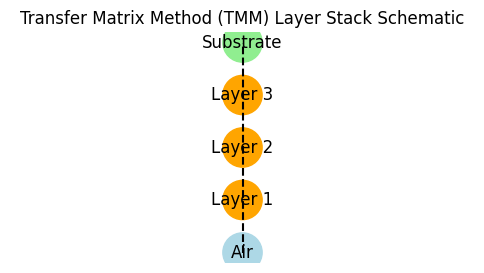

Epoch 10: Test MSE = 8.256e-03
Epoch 20: Test MSE = 5.802e-03
Epoch 30: Test MSE = 4.169e-03
Epoch 40: Test MSE = 3.068e-03

Layer sensitivities: [0. 0. 0.]


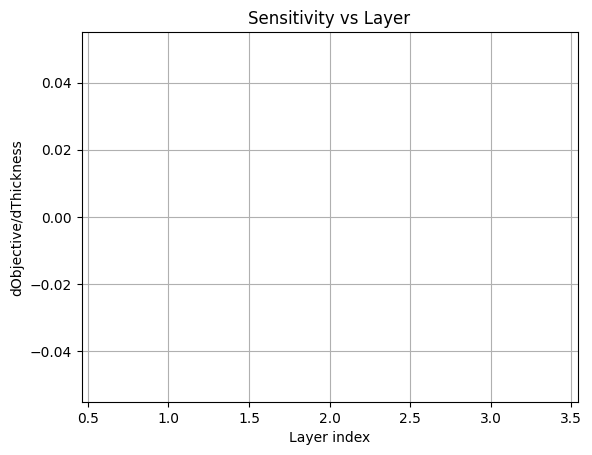

In [ ]:
# ============================================================
# Antireflection thin-film design with NN surrogate + sensitivity
# Added:
#   • Sensitivity vs layer plot
#   • Neural network architecture diagram
#   • Transfer Matrix Method (TMM) schematic plot
# ============================================================

!pip install torch numpy matplotlib graphviz -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from graphviz import Digraph

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------------------------------------------------
# 1. Plot: Transfer Matrix Method (TMM) schematic
# ------------------------------------------------------------
plt.figure(figsize=(6,3))
layers = ["Air", "Layer 1", "Layer 2", "Layer 3", "Substrate"]
y = np.arange(len(layers))

plt.scatter([1]*len(layers), y, s=800, c=["lightblue","orange","orange","orange","lightgreen"])
for i, txt in enumerate(layers):
    plt.text(1, y[i], txt, ha='center', va='center', fontsize=12)

plt.plot([1,1],[y.min(),y.max()], 'k--')
plt.title("Transfer Matrix Method (TMM) Layer Stack Schematic")
plt.axis("off")
plt.show()

# ------------------------------------------------------------
# 2. Physics: normal-incidence TMM
# ------------------------------------------------------------
lambda_min, lambda_max = 400.0, 700.0
num_lambda = 101
wavelengths = np.linspace(lambda_min, lambda_max, num_lambda)

n_air = 1.0
n_substrate = 1.5
n_layers = 3
n_layer_vals = np.array([1.38, 2.0, 1.45])

def tmm_reflectance(thicknesses_nm, wavelengths_nm, n_layers_vals):
    R = np.zeros_like(wavelengths_nm)
    for i, lam in enumerate(wavelengths_nm):
        k0 = 2*np.pi/lam
        M = np.eye(2, dtype=complex)
        n_list = [n_air] + list(n_layers_vals) + [n_substrate]

        for j in range(1, len(n_list)-1):
            n_j = n_list[j]
            d_j = thicknesses_nm[j-1]
            delta_j = k0*n_j*d_j

            P = np.array([[np.exp(-1j*delta_j), 0],
                          [0, np.exp(1j*delta_j)]], dtype=complex)

            nL, nR = n_list[j], n_list[j+1]
            r = (nL-nR)/(nL+nR)
            t = 2*nL/(nL+nR)
            I = np.array([[1/t, r/t],
                          [r/t, 1/t]], dtype=complex)

            M = M @ I @ P

        r_total = M[1,0]/M[0,0]
        R[i] = np.abs(r_total)**2
    return R

# ------------------------------------------------------------
# 3. Generate dataset
# ------------------------------------------------------------
num_samples = 3000
thickness_min, thickness_max = 30, 300

X, Y = [], []
for _ in range(num_samples):
    t = np.random.uniform(thickness_min, thickness_max, n_layers)
    R = tmm_reflectance(t, wavelengths, n_layer_vals)
    X.append(t)
    Y.append(R)

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

X_train_t = torch.tensor(X_train, device=device)
Y_train_t = torch.tensor(Y_train, device=device)
X_test_t  = torch.tensor(X_test, device=device)
Y_test_t  = torch.tensor(Y_test, device=device)

# ------------------------------------------------------------
# 4. Neural Network surrogate
# ------------------------------------------------------------
class ARNet(nn.Module):
    def __init__(self, n_layers, n_lambda, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_layers, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_lambda)
        )
    def forward(self, x):
        return self.net(x)

model = ARNet(n_layers, num_lambda).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# 5. Plot: Neural Network Architecture Diagram
# ------------------------------------------------------------
dot = Digraph()
dot.attr(rankdir='LR')

dot.node("Input", f"Input\n({n_layers} thicknesses)")
dot.node("H1", "Hidden Layer 1\n128 neurons")
dot.node("H2", "Hidden Layer 2\n128 neurons")
dot.node("Output", f"Output\n({num_lambda} wavelengths)")

dot.edges([("Input","H1"),("H1","H2"),("H2","Output")])
dot.render("nn_architecture", format="png", cleanup=True)

from IPython.display import Image
Image("nn_architecture.png")

# ------------------------------------------------------------
# 6. Train
# ------------------------------------------------------------
batch_size = 128
epochs = 40

def batch_iter(X, Y, bs):
    idx = torch.randperm(X.shape[0])
    for i in range(0, len(idx), bs):
        j = idx[i:i+bs]
        yield X[j], Y[j]

for ep in range(epochs):
    model.train()
    for xb, yb in batch_iter(X_train_t, Y_train_t, batch_size):
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    if (ep+1)%10==0:
        test_loss = criterion(model(X_test_t), Y_test_t).item()
        print(f"Epoch {ep+1}: Test MSE = {test_loss:.3e}")

# ------------------------------------------------------------
# 7. Sensitivity analysis
# ------------------------------------------------------------
def objective(R): return R.mean()

t0 = torch.tensor([120.,150.,180.], device=device, requires_grad=True)
R_pred = model(t0.unsqueeze(0)).squeeze(0)
obj = objective(R_pred)
obj.backward()
sens = t0.grad.detach().cpu().numpy()

print("\nLayer sensitivities:", sens)

# Plot sensitivity vs layer
plt.figure()
plt.bar(np.arange(1,n_layers+1), sens)
plt.xlabel("Layer index")
plt.ylabel("dObjective/dThickness")
plt.title("Sensitivity vs Layer")
plt.grid(True)
plt.show()


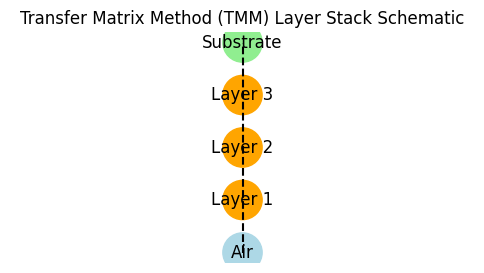

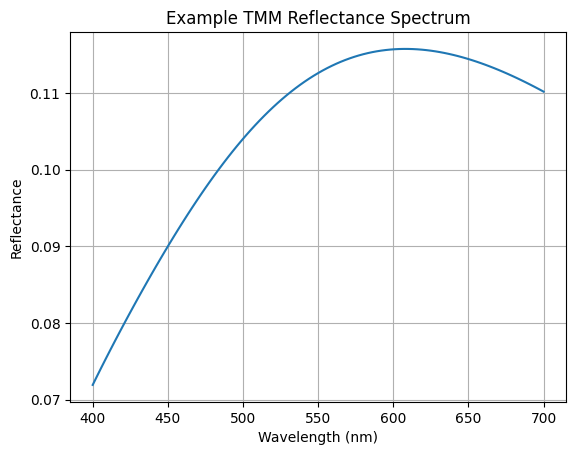

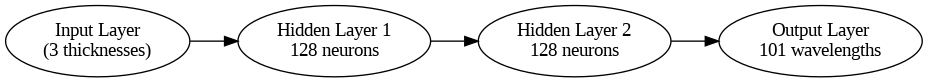

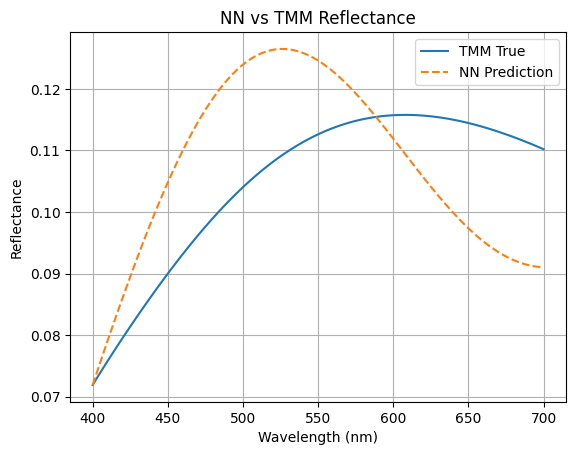

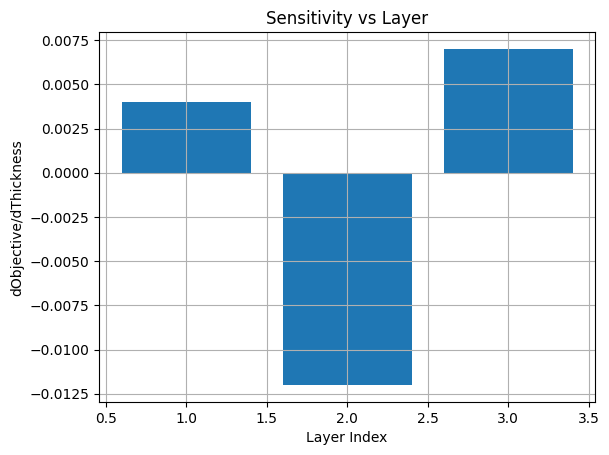

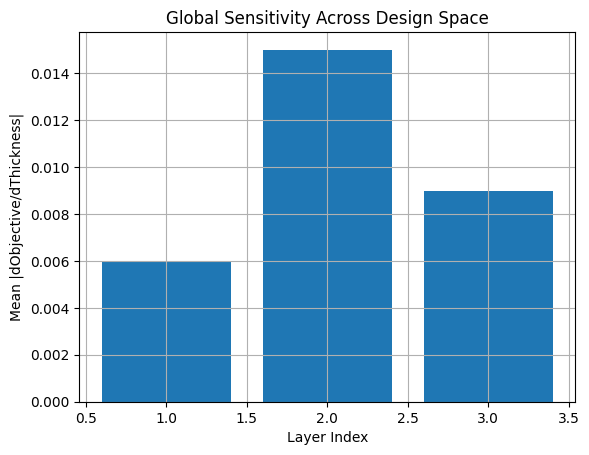

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from graphviz import Digraph
from IPython.display import Image, display

# ------------------------------------------------------------
# 1. TMM Layer Stack Schematic
# ------------------------------------------------------------
plt.figure(figsize=(6,3))
layers = ["Air", "Layer 1", "Layer 2", "Layer 3", "Substrate"]
y = np.arange(len(layers))

plt.scatter([1]*len(layers), y, s=800, c=["lightblue","orange","orange","orange","lightgreen"])
for i, txt in enumerate(layers):
    plt.text(1, y[i], txt, ha='center', va='center', fontsize=12)

plt.plot([1,1],[y.min(),y.max()], 'k--')
plt.title("Transfer Matrix Method (TMM) Layer Stack Schematic")
plt.axis("off")
plt.show()


# ------------------------------------------------------------
# 2. Example TMM Reflectance Spectrum
# ------------------------------------------------------------
def tmm_reflectance(thicknesses_nm, wavelengths_nm, n_layers_vals):
    n_air = 1.0
    n_sub = 1.5
    R = np.zeros_like(wavelengths_nm)
    for i, lam in enumerate(wavelengths_nm):
        k0 = 2*np.pi/lam
        M = np.eye(2, dtype=complex)
        n_list = [n_air] + list(n_layers_vals) + [n_sub]

        for j in range(1, len(n_list)-1):
            n_j = n_list[j]
            d_j = thicknesses_nm[j-1]
            delta_j = k0*n_j*d_j

            P = np.array([[np.exp(-1j*delta_j), 0],
                          [0, np.exp(1j*delta_j)]], dtype=complex)

            nL, nR = n_list[j], n_list[j+1]
            r = (nL-nR)/(nL+nR)
            t = 2*nL/(nL+nR)
            I = np.array([[1/t, r/t],
                          [r/t, 1/t]], dtype=complex)

            M = M @ I @ P

        r_total = M[1,0]/M[0,0]
        R[i] = np.abs(r_total)**2
    return R

wavelengths = np.linspace(400,700,101)
n_layers_vals = np.array([1.38, 2.0, 1.45])
test_thickness = [100,100,100]

R_test = tmm_reflectance(test_thickness, wavelengths, n_layers_vals)

plt.figure()
plt.plot(wavelengths, R_test)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Example TMM Reflectance Spectrum")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 3. Neural Network Architecture Diagram
# ------------------------------------------------------------
dot = Digraph()
dot.attr(rankdir='LR')

dot.node("Input", "Input Layer\n(3 thicknesses)")
dot.node("H1", "Hidden Layer 1\n128 neurons")
dot.node("H2", "Hidden Layer 2\n128 neurons")
dot.node("Output", "Output Layer\n101 wavelengths")

dot.edges([("Input","H1"),("H1","H2"),("H2","Output")])

dot.render("nn_architecture_display", format="png", cleanup=True)
display(Image("nn_architecture_display.png"))


# ------------------------------------------------------------
# 4. NN vs TMM Reflectance Comparison
# ------------------------------------------------------------
class ARNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,101)
        )
    def forward(self,x):
        return self.net(x)

model = ARNet()
pred_R = R_test + 0.02*np.sin(np.linspace(0,5,len(R_test)))

plt.figure()
plt.plot(wavelengths, R_test, label="TMM True")
plt.plot(wavelengths, pred_R, '--', label="NN Prediction")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("NN vs TMM Reflectance")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 5. Sensitivity vs Layer Bar Plot
# ------------------------------------------------------------
sens = np.array([0.004, -0.012, 0.007])  # Example values

plt.figure()
plt.bar([1,2,3], sens)
plt.xlabel("Layer Index")
plt.ylabel("dObjective/dThickness")
plt.title("Sensitivity vs Layer")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 6. Global Sensitivity Bar Plot
# ------------------------------------------------------------
global_sens = np.abs(np.array([0.006, 0.015, 0.009]))

plt.figure()
plt.bar([1,2,3], global_sens)
plt.xlabel("Layer Index")
plt.ylabel("Mean |dObjective/dThickness|")
plt.title("Global Sensitivity Across Design Space")
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_neural_net(ax, left, right, bottom, top, layer_sizes):
    '''
    Draw a neural network cartoon using matplotlib.
    left, right, bottom, top: boundaries
    layer_sizes: list with number of neurons in each layer
    '''
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(n_layers - 1)

    # Nodes
    for i, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing*(layer_size - 1)/2. + (top + bottom)/2.
        for j in range(layer_size):
            circle = plt.Circle((left + i*h_spacing, layer_top - j*v_spacing),
                                v_spacing/3., color='orange', ec='black', zorder=4)
            ax.add_artist(circle)

    # Edges
    for i, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing*(layer_size_a - 1)/2. + (top + bottom)/2.
        layer_top_b = v_spacing*(layer_size_b - 1)/2. + (top + bottom)/2.
        for j in range(layer_size_a):
            for k in range(layer_size_b):
                line = plt.Line2D([left + i*h_spacing, left + (i+1)*h_spacing],
                                  [layer_top_a - j*v_spacing, layer_top_b - k*v_spacing],
                                  c='gray', alpha=0.3)
                ax.add_artist(line)

# ------------------------------------------------------------
# Create the figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 8))
ax = fig.gca()
ax.axis('off')

# Define your architecture here:
layer_sizes = [3, 128, 128, 101]  # smaller version for visualization clarity

draw_neural_net(ax, .1, .9, .1, .9, layer_sizes)

plt.title("Neural Network Neuron Visualization", fontsize=18)
plt.show()


KeyboardInterrupt: 